# kmeans_segmentation

- Done By: Kedar Raju Pawar
- date:2026-02-25 time: 19:16:00

In [18]:
import pandas as pd
from utils_preprocessing import (
    preprocess_laptop_features,
    get_hardware_features,
    get_market_features
)


## load data

In [20]:
df=pd.read_csv("../../02_Data_Management/04_Processed_Data/analytics_dataset.csv")

df = preprocess_laptop_features(df)
df.columns

Index(['Company', 'laptop_type', 'screen_size_inch',
       'display_resolution_width', 'display_resolution_height', 'panel_type',
       'is_touchscreen', 'resolution_class', 'cpu_brand', 'cpu_family',
       'cpu_generation', 'clock_speed_ghz', 'cpu_tier', 'gpu_brand', 'ram_gb',
       'ssd_gb', 'hdd_gb', 'flash_gb', 'hybrid_gb', 'total_storage_gb',
       'weight_kg', 'weight_class', 'price_band', 'Price', 'is_price_outlier',
       'cpu_tier_numeric', 'ssd_indicator'],
      dtype='object')

In [16]:
ssd_indicator = (df["ssd_gb"] > 0).astype(int)
ssd_indicator.value_counts()

ssd_gb
1    670
0    330
Name: count, dtype: int64

### Objective

- To evaluate whether pricing aligns logically with **hardware capabilities** and uncover deeper **business insights**.



#### 01. Hardware-Based Clustering (Exclude Price)

- To identify natural product segments based purely on technical specifications without pricing bias.


In [21]:
X_hardware = get_hardware_features(df)

#### 02. Market-Based Clustering (Include Price)


- To analyze how hardware configurations translate into pricing strategy and market positioning.

In [22]:
X_market = get_market_features(df)

#### 03 Determine Optimal K

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_hardware_scaled = scaler.fit_transform(X_hardware)
X_market_scaled = scaler.fit_transform(X_market)

##### 03A. Hardware-Based Clustering (Exclude Price)

###### A — Find Optimal Number of Clusters (Elbow Method)

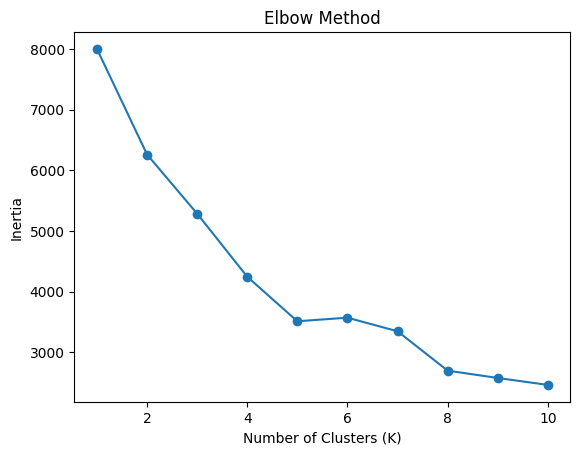

In [33]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_hardware_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

###### B — Silhouette Score

In [47]:
from sklearn.metrics import silhouette_score

print("Hardware Base Clustering Silhouette Score")
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_hardware_scaled)
    score = silhouette_score(X_hardware_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.4f}")

Hardware Base Clustering Silhouette Score
K=2, Silhouette Score=0.2172
K=3, Silhouette Score=0.2329
K=4, Silhouette Score=0.2893
K=5, Silhouette Score=0.3252
K=6, Silhouette Score=0.2362
K=7, Silhouette Score=0.2408
K=8, Silhouette Score=0.3071
K=9, Silhouette Score=0.3133
K=10, Silhouette Score=0.3137


###### C - Fit Final KMeans Model

In [49]:
kmeans = KMeans(n_clusters=5, random_state=42)
df["hardware_cluster"] = kmeans.fit_predict(X_hardware_scaled)

###### D - Interpret Clusters

In [50]:
df.groupby("hardware_cluster").mean(numeric_only=True)

,screen_size_inch,display_resolution_width,display_resolution_height,is_touchscreen,cpu_generation,clock_speed_ghz,ram_gb,ssd_gb,hdd_gb,flash_gb,hybrid_gb,total_storage_gb,weight_kg,Price,cpu_tier_numeric,ssd_indicator,cluster,Market_cluster
hardware_cluster,,,,,,,,,,,,,,,,,,
0,13.658824,2356.739496,1343.798319,1.000000,7.223301,1.605042,9.899160,332.504202,86.050420,0.000000,0.000000,418.554622,1.443193,82322.892182,4.403361,0.915966,0.008403,0.714286
1,13.985455,1531.272727,871.745455,0.090909,8.000000,1.009091,4.309091,21.818182,277.381818,28.509091,0.000000,327.709091,1.666727,22257.744218,1.281818,0.172727,1.781818,1.890909
2,14.777975,1913.291139,1081.488608,0.000000,6.997268,1.837975,8.065823,268.212658,75.179747,1.296203,0.000000,344.688608,1.838354,61296.665268,4.222785,0.994937,1.865823,1.030380
3,16.591447,2149.473684,1209.078947,0.052632,6.837838,1.907895,15.118421,283.789474,986.868421,0.000000,0.000000,1270.657895,3.010132,99690.735789,4.894737,0.973684,0.986842,0.585526
4,15.744643,1684.553571,948.214286,0.035714,6.771144,1.959821,6.142857,0.571429,925.250000,1.428571,6.839286,934.089286,2.227723,37355.664086,3.772321,0.004464,1.236607,1.852679


- **Conclusion**:
- Hardware segmentation revealed more nuanced product identities independent of pricing:
    - Entry-level basic machines
    - Storage-heavy HDD laptops
    - Balanced productivity systems
    - Lightweight premium ultrabooks
    - High-performance/gaming-oriented machines

- Although separation was weaker statistically, this approach uncovered true technical differentiation between products.

###### E. Save dataset with clusters

In [40]:
df.to_csv("hardware_clustered_laptops.csv", index=False)

##### 03B. Market-Based Clustering (Include Price)

###### A — Find Optimal Number of Clusters (Elbow Method)

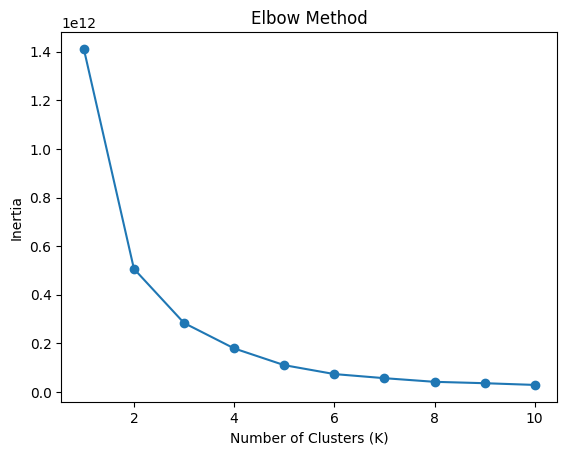

In [41]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_market)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

###### B — Silhouette Score

In [48]:
from sklearn.metrics import silhouette_score

print("Market-Base Clustering Silhouette Score")
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_market)
    score = silhouette_score(X_market, labels)
    print(f"K={k}, Silhouette Score={score:.4f}")

Market-Base Clustering Silhouette Score
K=2, Silhouette Score=0.6325
K=3, Silhouette Score=0.5787
K=4, Silhouette Score=0.5659
K=5, Silhouette Score=0.5698
K=6, Silhouette Score=0.5608
K=7, Silhouette Score=0.5548
K=8, Silhouette Score=0.5494
K=9, Silhouette Score=0.5496
K=10, Silhouette Score=0.5356


###### C - Fit Final KMeans Model

In [44]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Market_cluster"] = kmeans.fit_predict(X_market)

###### D - Interpret Clusters

In [51]:
df.groupby("Market_cluster").mean(numeric_only=True)

,screen_size_inch,display_resolution_width,display_resolution_height,is_touchscreen,cpu_generation,clock_speed_ghz,ram_gb,ssd_gb,hdd_gb,flash_gb,hybrid_gb,total_storage_gb,weight_kg,Price,cpu_tier_numeric,ssd_indicator,hardware_cluster,cluster
Market_cluster,,,,,,,,,,,,,,,,,,
0,14.731818,2073.380682,1176.102273,0.204545,6.948328,1.815341,10.045455,277.170455,324.125000,4.363636,0.000000,605.659091,1.895710,78619.895345,4.616477,0.928977,1.926136,1.258523
1,15.746739,2499.304348,1418.956522,0.239130,6.795181,1.967391,17.478261,439.565217,467.478261,2.782609,0.000000,909.826087,2.651522,143414.731565,4.956522,0.989130,2.163043,0.956522
2,15.135791,1706.719424,961.582734,0.091727,6.973105,1.685252,6.057554,95.633094,486.705036,3.913669,2.755396,589.007194,2.026169,34369.174360,3.311151,0.453237,2.473022,1.492806


- **Conclusion**:
- The market segmentation produced strong cluster separation (high silhouette score), indicating that laptops are naturally grouped into clear pricing tiers:
    
    - Budget Segment → Low RAM, HDD-heavy systems, lower CPU tier
    
    - Mid-Range Segment → Balanced specifications, strong SSD presence
    
    - Premium Segment → High RAM, top CPU tiers, high-resolution displays

- This suggests that price strongly structures the laptop market, forming clear economic tiers.

###### E. Save dataset with clusters

In [46]:
df.to_csv("Market_clustered_laptops.csv", index=False)

## Final Insights:

- The laptop market is clearly organized around pricing tiers; however, within those tiers, distinct hardware identities exist.

- Market clustering explains how laptops are priced, while hardware clustering explains what laptops fundamentally are.

- Both perspectives together provide a complete understanding of product structure and market positioning.